# Fase 4 CRISP-DM — Modeling: Segmentación RFM de Clientes
**Proyecto:** Customer Behavior Analysis — Olist Brazilian E-Commerce  
**Objetivo:** Segmentar la base de clientes usando el modelo RFM (Recency, Frequency, Monetary)  
para identificar grupos accionables: Champions, Loyal, At Risk, Lost y New Customers.

**¿Por qué RFM?** Es el framework estándar de segmentación en e-commerce: interpretable,  
basado en comportamiento real y directamente accionable por equipos de marketing y retención.

**Fuente de datos:** `data/olist_master.csv` (Fase 3)

---

## 0. Imports y configuración

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

ROOT = Path().resolve().parent
CSV  = ROOT / "data" / "olist_master.csv"
DASH = ROOT / "dashboard"

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.float_format", "{:.2f}".format)

print(f"CSV: data/{CSV.name}  →  existe: {CSV.exists()}")

CSV: data/olist_master.csv  →  existe: True


---
## 1. Carga de datos y fecha de referencia
La fecha de referencia (`snapshot_date`) es el día siguiente al último pedido del dataset.  
Esto simula el punto de vista de un analista que ejecuta el análisis al cierre del período.

In [2]:
df = pd.read_csv(CSV, parse_dates=["order_purchase_timestamp"])

# Fecha de referencia: un día después del último pedido
snapshot_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

print(f"Pedidos cargados:  {len(df):,}")
print(f"Clientes únicos:   {df['customer_unique_id'].nunique():,}")
print(f"Primer pedido:     {df['order_purchase_timestamp'].min().date()}")
print(f"Último pedido:     {df['order_purchase_timestamp'].max().date()}")
print(f"Snapshot date:     {snapshot_date.date()}")

Pedidos cargados:  96,457
Clientes únicos:   93,337
Primer pedido:     2016-09-15
Último pedido:     2018-08-29
Snapshot date:     2018-08-30


---
## 2. Cálculo de métricas RFM
Para cada `customer_unique_id` calculamos:

| Métrica | Definición | Interpretación |
|---------|-----------|----------------|
| **R** (Recency) | Días desde la última compra hasta `snapshot_date` | Menor = más reciente = mejor |
| **F** (Frequency) | Número de pedidos únicos | Mayor = más leal = mejor |
| **M** (Monetary) | Suma de `price_total` de todos sus pedidos | Mayor = más valioso = mejor |

In [3]:
rfm = (
    df.groupby("customer_unique_id", as_index=False)
    .agg(
        last_purchase  =("order_purchase_timestamp", "max"),
        frequency      =("order_id",                 "nunique"),
        monetary       =("price_total",               "sum"),
    )
)

# Recency: días desde la última compra hasta snapshot_date
rfm["recency"] = (snapshot_date - rfm["last_purchase"]).dt.days
rfm = rfm.drop(columns="last_purchase")

print(f"Clientes en tabla RFM: {len(rfm):,}")
print(f"\nDistribución de Frequency:")
print(rfm["frequency"].value_counts().sort_index().head(8).to_string())
print(f"\nEstadísticas RFM:")
display(rfm[["recency", "frequency", "monetary"]].describe().round(1))

Clientes en tabla RFM: 93,337

Distribución de Frequency:
frequency
1    90536
2     2573
3      181
4       28
5        9
6        5
7        3
9        1

Estadísticas RFM:


,recency,frequency,monetary
count,93337.00,93337.00,93337.00
mean,237.90,1.00,141.60
std,152.60,0.20,215.70
min,1.00,1.00,0.80
25%,114.00,1.00,47.60
50%,219.00,1.00,89.70
75%,346.00,1.00,154.70
max,714.00,15.00,13440.00


---
## 3. Scoring: quintiles para R/M, cortes de negocio para F
**Corrección crítica (revisión de portfolio, prioridad 1 -- la más grave detectada en la
auditoría de este proyecto):** una versión anterior de este notebook usaba
`rank(method='first')` + `qcut(q=5)` para las tres métricas por igual. Frequency tiene **97.0%**
de los clientes con `frequency=1` (verificado abajo), así que los 4 primeros quintiles de F caían
ÍNTEGRAMENTE dentro de ese empate, y `rank(method='first')` desempataba por el **orden de fila**
tras el `groupby` -- esencialmente el orden alfabético del hash `customer_unique_id`, no
comportamiento real. Consecuencia verificable: todo cliente con F_score 1-4 tenía *exactamente* 1
pedido, así que segmentos como "Loyal"/"At Risk" (definidos por F≥3) quedaban decididos por ruido
para el 97% de la base -- y de hecho "At Risk" y "Lost" resultaban estadísticamente
indistinguibles entre sí (misma recency media, mismo M_score medio ~3.0 en TODOS los segmentos:
la firma de una asignación aleatoria).

**Solución:** F_score se define ahora con **cortes de negocio explícitos** en vez de quintiles
automáticos, reflejando la distribución real (90.536 clientes con F=1, 2.573 con F=2, 228 con
F≥3 -- ver el value_counts de la Sección 2):
- `frequency == 1` → `F_score = 1` (un solo pedido: la inmensa mayoría de la base)
- `frequency == 2` → `F_score = 3` (ha repetido una vez)
- `frequency >= 3` → `F_score = 5` (recompra real, minoría genuina)

Esto da solo 3 niveles de F en vez de 5 -- **honesto dado que los datos no soportan más
resolución** -- y elimina el desempate arbitrario: ya no hay ningún cliente cuyo F_score dependa
del orden de una tabla. R_score y M_score conservan el scoring por quintiles (ambas métricas sí
tienen varianza continua real).

In [4]:
def quintile_score(series: pd.Series, ascending: bool = True) -> pd.Series:
    """Asigna score 1-5 por quintiles. ascending=True → valor alto = score alto."""
    ranked = series.rank(method="first", ascending=ascending)
    return pd.qcut(ranked, q=5, labels=[1, 2, 3, 4, 5]).astype(int)

def frequency_score(freq: pd.Series) -> pd.Series:
    """Cortes de negocio (no quintiles): F=1 -> 1, F=2 -> 3, F>=3 -> 5.
    Ver nota de la Sección 3 sobre por qué un quintil automático no es defendible aquí."""
    return pd.cut(freq, bins=[0, 1, 2, freq.max()], labels=[1, 3, 5], include_lowest=True).astype(int)

# R: recency inversa (menor días = más reciente = mejor = score 5)
rfm["R_score"] = quintile_score(rfm["recency"],   ascending=False)  # invertido
rfm["F_score"] = frequency_score(rfm["frequency"])
rfm["M_score"] = quintile_score(rfm["monetary"],  ascending=True)

# Score compuesto: media de los tres scores (escala 1-5)
rfm["RFM_score"] = (rfm[["R_score", "F_score", "M_score"]].mean(axis=1)).round(2)

# String concatenado para lookup de segmento
rfm["RFM_string"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

print("Distribución de R_score:")
print(rfm["R_score"].value_counts().sort_index().to_string())
print("\nDistribución de F_score (cortes de negocio, no quintiles):")
print(rfm["F_score"].value_counts().sort_index().to_string())
print(f"  -> {(rfm['F_score']==1).sum():,} clientes con F_score=1 tienen exactamente 1 pedido "
      f"({(rfm['F_score']==1).mean():.1%} de la base)")
print("\nPrimeras filas:")
display(rfm.head(5))

Distribución de R_score:
R_score
1    18668
2    18667
3    18667
4    18667
5    18668

Distribución de F_score (cortes de negocio, no quintiles):
F_score
1    90536
3     2573
5      228
  -> 90,536 clientes con F_score=1 tienen exactamente 1 pedido (97.0% de la base)

Primeras filas:


,customer_unique_id,frequency,monetary,recency,R_score,F_score,M_score,RFM_score,RFM_string
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,112,4,1,4,3.00,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,115,4,1,1,2.00,411
2,0000f46a3911fa3c0805444483337064,1,69.00,537,1,1,2,1.33,112
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,321,2,1,1,1.33,211
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,288,2,1,5,2.67,215


### 3.1 Verificación: ¿sigue habiendo firma de asignación aleatoria?
Chequeo directo de que la corrección funcionó: si F_score siguiera sin discriminar, el M_score
medio sería ~3.0 en todos los grupos de F (como antes). Comparamos M_score medio por F_score.

In [5]:
check_m_by_f = rfm.groupby("F_score")["M_score"].agg(["mean", "std", "count"]).round(3)
print("M_score medio por F_score (si la corrección funcionó, NO deberían ser ~3.0 e indistinguibles):")
display(check_m_by_f)

M_score medio por F_score (si la corrección funcionó, NO deberían ser ~3.0 e indistinguibles):


,mean,std,count
F_score,,,
1,2.96,1.41,90536
3,4.11,1.07,2573
5,4.58,0.83,228


---
## 4. Asignación de segmentos
Definimos 5 segmentos basados en umbrales de R_score, F_score y M_score:

| Segmento | Regla | Descripción de negocio |
|----------|-------|------------------------|
| **Champions** | R≥4, F≥4 | Compraron recientemente y con alta frecuencia |
| **Loyal** | F≥3, R≥3 (no Champions) | Frecuentes y recientes, pero no en el top |
| **New Customers** | R≥4, F=1 | Primera compra reciente — pendiente de fidelizar |
| **At Risk** | R≤2, F≥3 | Fueron frecuentes pero no compran hace tiempo |
| **Lost** | R≤2, F≤2 | Baja frecuencia y mucho tiempo sin comprar |

In [6]:
def assign_segment(row: pd.Series) -> str:
    r, f = row["R_score"], row["F_score"]
    if r >= 4 and f >= 4:
        return "Champions"
    if f >= 3 and r >= 3:
        return "Loyal"
    if r >= 4 and f == 1:
        return "New Customers"
    if r <= 2 and f >= 3:
        return "At Risk"
    if r <= 2 and f <= 2:
        return "Lost"
    return "Others"  # segmento residual para combinaciones intermedias

rfm["segment"] = rfm.apply(assign_segment, axis=1)

seg_counts = rfm["segment"].value_counts()
print("Clientes por segmento:")
print(seg_counts.to_string())
print(f"\nTotal clasificados: {len(rfm):,}  |  Segmentos: {rfm['segment'].nunique()}")

Clientes por segmento:
segment
Lost             36344
New Customers    36132
Others           18060
Loyal             1689
At Risk            991
Champions          121

Total clasificados: 93,337  |  Segmentos: 6


---
## 5. Tabla resumen por segmento
Calculamos las métricas clave por segmento para entender el perfil de cada grupo.

In [7]:
seg_summary = (
    rfm.groupby("segment", as_index=False)
    .agg(
        n_customers      =("customer_unique_id", "count"),
        pct_customers    =("customer_unique_id", lambda x: len(x) / len(rfm) * 100),
        avg_recency_days =("recency",            "mean"),
        avg_frequency    =("frequency",           "mean"),
        avg_monetary     =("monetary",            "mean"),
        total_revenue    =("monetary",            "sum"),
        pct_revenue      =("monetary",            lambda x: x.sum() / rfm["monetary"].sum() * 100),
    )
    .sort_values("avg_monetary", ascending=False)
)

seg_summary = seg_summary.round({
    "pct_customers": 1, "avg_recency_days": 0, "avg_frequency": 2,
    "avg_monetary": 1, "total_revenue": 0, "pct_revenue": 1,
})

display(seg_summary.set_index("segment"))
seg_summary.to_csv(ROOT / "data" / "rfm_segments.csv", index=False)
print("\nTabla guardada en data/rfm_segments.csv")

,n_customers,pct_customers,avg_recency_days,avg_frequency,avg_monetary,total_revenue,pct_revenue
segment,,,,,,,
Champions,121,0.10,89.00,3.51,461.50,55843.00,0.40
Loyal,1689,1.80,135.00,2.03,253.50,428207.00,3.20
At Risk,991,1.10,382.00,2.08,246.60,244358.00,1.80
New Customers,36132,38.70,90.00,1.00,140.30,5069448.00,38.40
Lost,36344,38.90,395.00,1.00,139.60,5074720.00,38.40
Others,18060,19.30,220.00,1.00,129.90,2345775.00,17.70



Tabla guardada en data/rfm_segments.csv


---
## 6. Visualizaciones

### 6.1 Scatter plot RFM: Recency vs Monetary coloreado por segmento
Cada punto es un cliente. El tamaño del punto representa la Frequency.  
Esta visualización es el equivalente al treemap en un espacio 2D continuo.

C:\Users\pardo\AppData\Local\Temp\ipykernel_14860\1722462790.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_per_seg = rfm.groupby("segment", group_keys=False).apply(


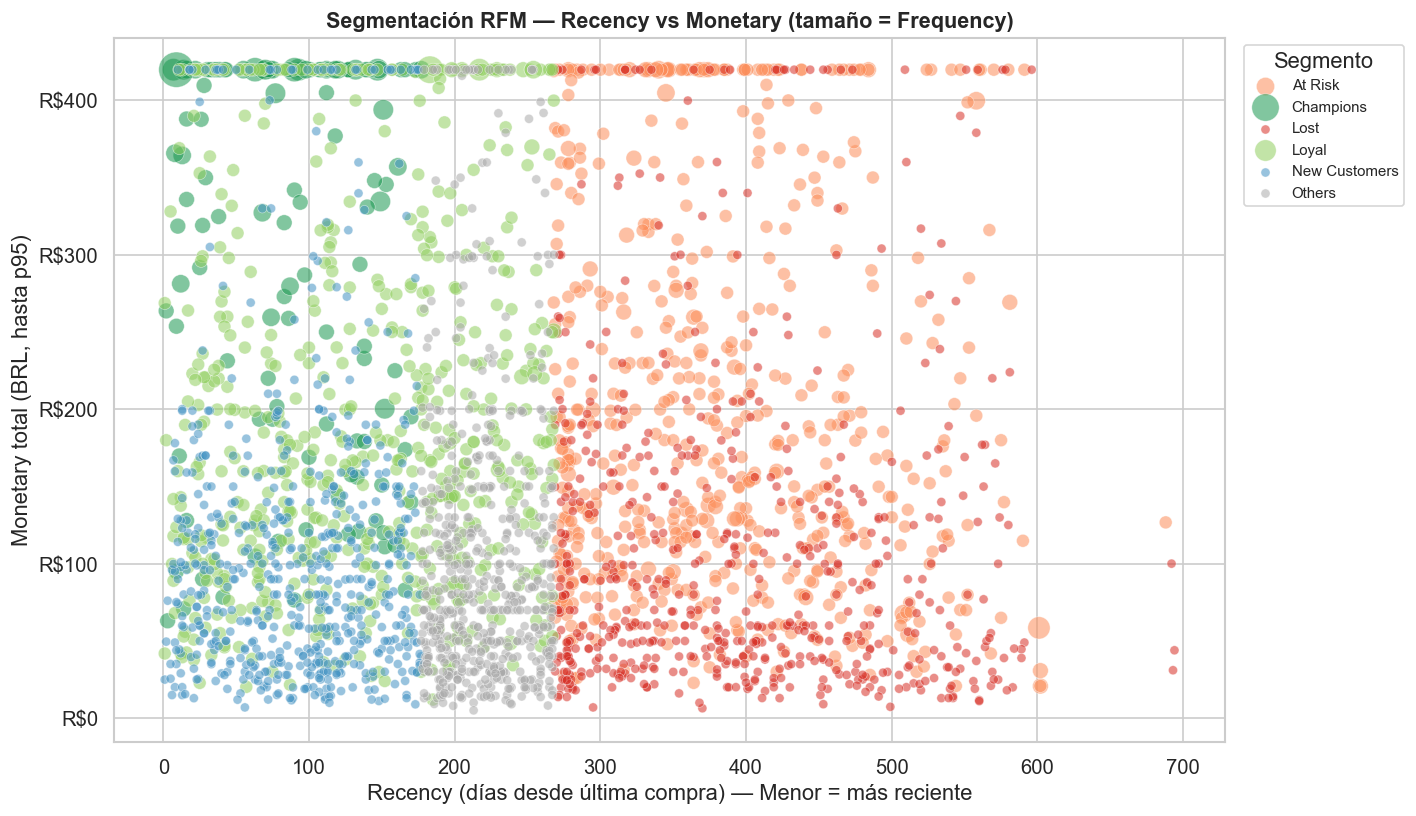

In [8]:
# Paleta de colores por segmento
SEG_COLORS = {
    "Champions":     "#1a9850",
    "Loyal":         "#91cf60",
    "New Customers": "#4393c3",
    "At Risk":       "#fc8d59",
    "Lost":          "#d73027",
    "Others":        "#aaaaaa",
}

# Muestra estratificada para no saturar el gráfico
sample_per_seg = rfm.groupby("segment", group_keys=False).apply(
    lambda g: g.sample(min(len(g), 600), random_state=42)
)

# Clippeamos monetary en p95 para visualización
p95_m = rfm["monetary"].quantile(0.95)
sample_plot = sample_per_seg.copy()
sample_plot["monetary_clipped"] = sample_plot["monetary"].clip(upper=p95_m)

fig, ax = plt.subplots(figsize=(12, 7))

for seg, grp in sample_plot.groupby("segment"):
    ax.scatter(
        grp["recency"],
        grp["monetary_clipped"],
        s=grp["frequency"] * 30,        # tamaño proporcional a frecuencia
        c=SEG_COLORS.get(seg, "gray"),
        alpha=0.55, edgecolors="white", linewidths=0.4,
        label=seg, rasterized=True,
    )

ax.set_title("Segmentación RFM — Recency vs Monetary (tamaño = Frequency)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Recency (días desde última compra) — Menor = más reciente")
ax.set_ylabel("Monetary total (BRL, hasta p95)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
ax.legend(title="Segmento", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(DASH / "rfm_scatter.png", bbox_inches="tight")
plt.show()

### 6.2 Distribución de clientes y revenue por segmento (barras duales)
Compara el peso de cada segmento en número de clientes vs en revenue generado.  
Si Champions son pocos pero generan mucho revenue, son prioritarios para retención.

C:\Users\pardo\AppData\Local\Temp\ipykernel_14860\1863969302.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(seg_order, rotation=15, ha="right")
C:\Users\pardo\AppData\Local\Temp\ipykernel_14860\1863969302.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(seg_order, rotation=15, ha="right")


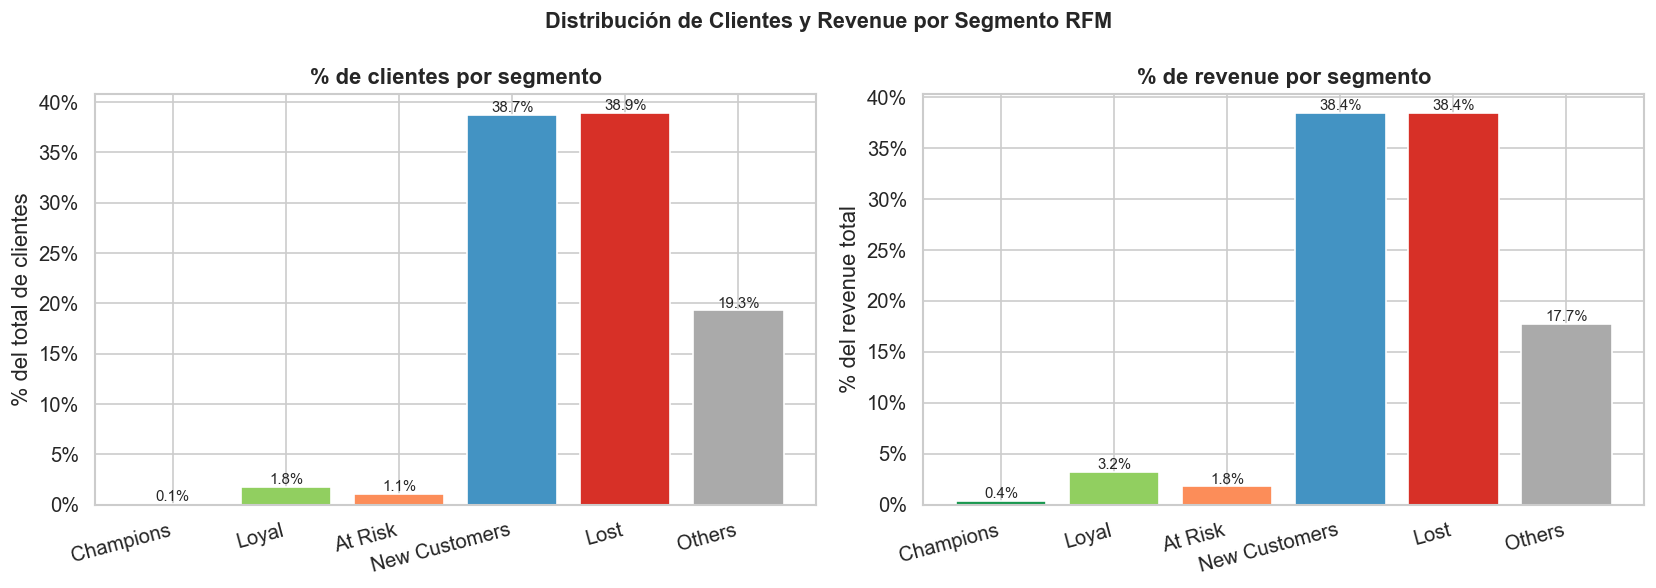

In [9]:
seg_order = seg_summary.sort_values("avg_monetary", ascending=False)["segment"].tolist()
seg_display = seg_summary.set_index("segment").loc[seg_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- % clientes --
colors_bar = [SEG_COLORS.get(s, "gray") for s in seg_order]
axes[0].bar(seg_order, seg_display["pct_customers"], color=colors_bar, edgecolor="white")
for i, (seg, row) in enumerate(seg_display.iterrows()):
    axes[0].text(i, row["pct_customers"] + 0.3, f"{row['pct_customers']:.1f}%",
                 ha="center", fontsize=9)
axes[0].set_title("% de clientes por segmento", fontweight="bold")
axes[0].set_ylabel("% del total de clientes")
axes[0].set_xticklabels(seg_order, rotation=15, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# -- % revenue --
axes[1].bar(seg_order, seg_display["pct_revenue"], color=colors_bar, edgecolor="white")
for i, (seg, row) in enumerate(seg_display.iterrows()):
    axes[1].text(i, row["pct_revenue"] + 0.3, f"{row['pct_revenue']:.1f}%",
                 ha="center", fontsize=9)
axes[1].set_title("% de revenue por segmento", fontweight="bold")
axes[1].set_ylabel("% del revenue total")
axes[1].set_xticklabels(seg_order, rotation=15, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.suptitle("Distribución de Clientes y Revenue por Segmento RFM",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "rfm_distribution.png", bbox_inches="tight")
plt.show()

### 6.3 Heatmap de scores medios por segmento
Muestra el perfil promedio de R, F y M para cada segmento.  
Valida que la segmentación tiene coherencia: Champions debe tener los tres scores altos.

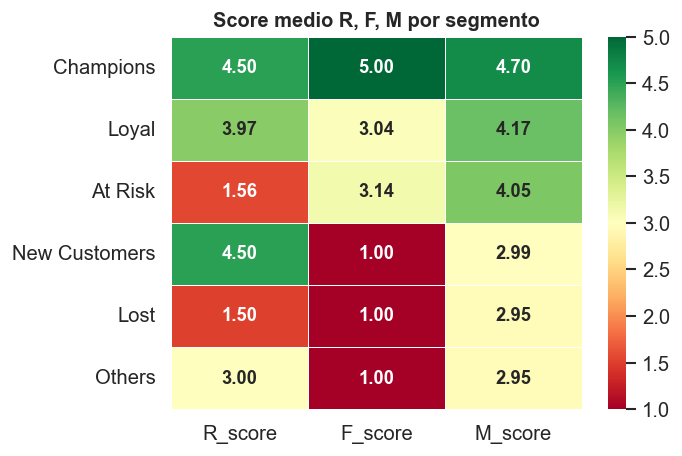

Scores medios por segmento:


,R_score,F_score,M_score
segment,,,
Champions,4.50,5.00,4.70
Loyal,3.97,3.04,4.17
At Risk,1.56,3.14,4.05
New Customers,4.50,1.00,2.99
Lost,1.50,1.00,2.95
Others,3.00,1.00,2.95


In [10]:
score_heatmap = (
    rfm.groupby("segment")[["R_score", "F_score", "M_score"]]
    .mean()
    .round(2)
    .loc[seg_order]  # orden por valor monetario descendente
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    score_heatmap,
    annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=1, vmax=5,
    linewidths=0.5, ax=ax,
    annot_kws={"size": 11, "weight": "bold"},
)
ax.set_title("Score medio R, F, M por segmento", fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(DASH / "rfm_heatmap_segments.png", bbox_inches="tight")
plt.show()

print("Scores medios por segmento:")
display(score_heatmap)

### 6.4 Distribución de Recency y Monetary por segmento (violin plots)

C:\Users\pardo\AppData\Local\Temp\ipykernel_14860\1870607307.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


C:\Users\pardo\AppData\Local\Temp\ipykernel_14860\1870607307.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(seg_violin_order, rotation=15, ha="right")
C:\Users\pardo\AppData\Local\Temp\ipykernel_14860\1870607307.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


C:\Users\pardo\AppData\Local\Temp\ipykernel_14860\1870607307.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(seg_violin_order, rotation=15, ha="right")


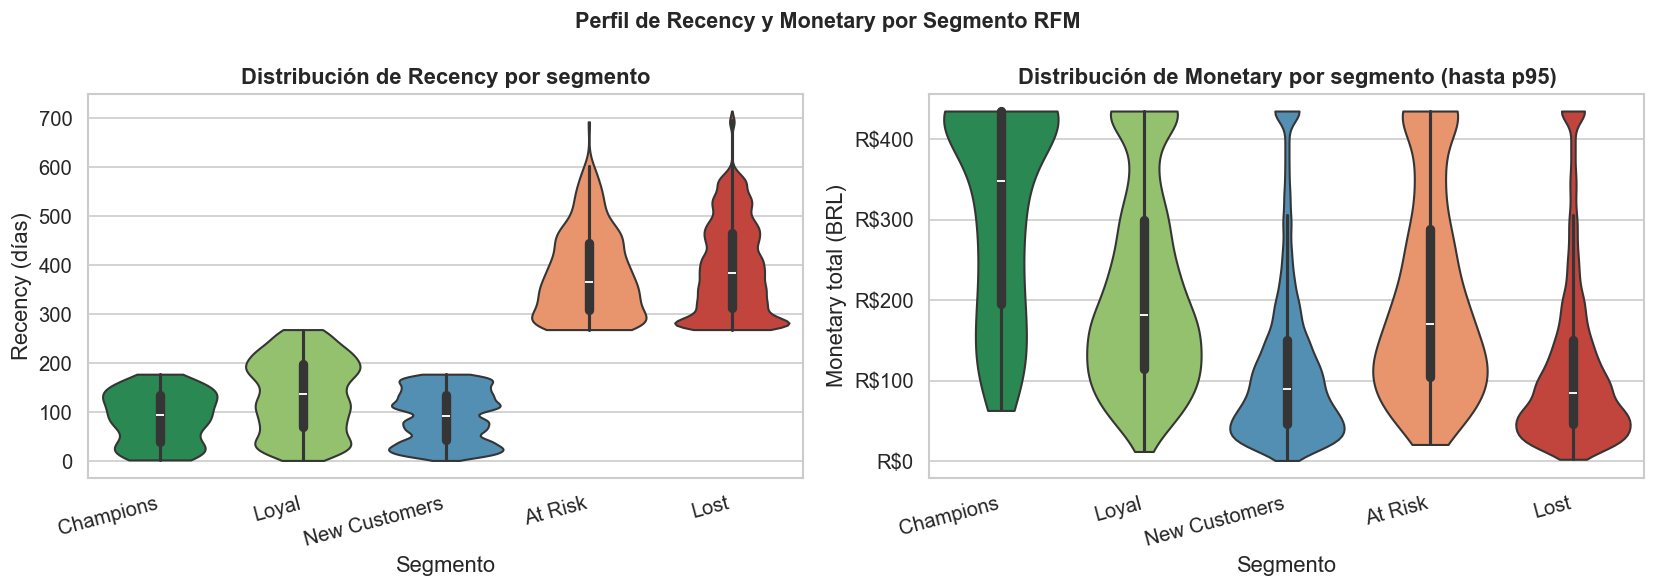

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Orden para violines: de mejor a peor segmento
rfm_plot = rfm[rfm["segment"] != "Others"].copy()
rfm_plot["monetary_clipped"] = rfm_plot["monetary"].clip(upper=rfm_plot["monetary"].quantile(0.95))

seg_palette = {s: SEG_COLORS[s] for s in SEG_COLORS if s != "Others"}
seg_violin_order = ["Champions", "Loyal", "New Customers", "At Risk", "Lost"]

sns.violinplot(
    data=rfm_plot, x="segment", y="recency",
    order=seg_violin_order, palette=seg_palette,
    ax=axes[0], inner="box", cut=0,
)
axes[0].set_title("Distribución de Recency por segmento", fontweight="bold")
axes[0].set_xlabel("Segmento")
axes[0].set_ylabel("Recency (días)")
axes[0].set_xticklabels(seg_violin_order, rotation=15, ha="right")

sns.violinplot(
    data=rfm_plot, x="segment", y="monetary_clipped",
    order=seg_violin_order, palette=seg_palette,
    ax=axes[1], inner="box", cut=0,
)
axes[1].set_title("Distribución de Monetary por segmento (hasta p95)", fontweight="bold")
axes[1].set_xlabel("Segmento")
axes[1].set_ylabel("Monetary total (BRL)")
axes[1].set_xticklabels(seg_violin_order, rotation=15, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))

plt.suptitle("Perfil de Recency y Monetary por Segmento RFM",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "rfm_violin.png", bbox_inches="tight")
plt.show()

---
## 7. Exportar tabla RFM completa
Guardamos la tabla RFM con scores y segmentos para uso en el notebook de evaluación.

In [12]:
rfm_out = ROOT / "data" / "olist_rfm.csv"
rfm.to_csv(rfm_out, index=False)

size_mb = rfm_out.stat().st_size / 1024 / 1024
print(f"Exportado: data/{rfm_out.name}")
print(f"Tamaño:    {size_mb:.2f} MB")
print(f"Filas:     {len(rfm):,}")
print(f"Columnas:  {list(rfm.columns)}")

Exportado: data/olist_rfm.csv
Tamaño:    6.16 MB
Filas:     93,337
Columnas:  ['customer_unique_id', 'frequency', 'monetary', 'recency', 'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_string', 'segment']


---
## 8. Resumen ejecutivo — Segmentación RFM

### Hallazgos clave

In [13]:
champs  = seg_summary[seg_summary["segment"] == "Champions"].iloc[0] if "Champions" in seg_summary["segment"].values else None
lost    = seg_summary[seg_summary["segment"] == "Lost"].iloc[0]      if "Lost"       in seg_summary["segment"].values else None
at_risk = seg_summary[seg_summary["segment"] == "At Risk"].iloc[0]   if "At Risk"    in seg_summary["segment"].values else None
new_c   = seg_summary[seg_summary["segment"] == "New Customers"].iloc[0] if "New Customers" in seg_summary["segment"].values else None

print("=" * 65)
print("RESUMEN EJECUTIVO — SEGMENTACIÓN RFM")
print("=" * 65)
print(f"\nTotal clientes analizados: {len(rfm):,}")
print(f"\n{'Segmento':<16} {'Clientes':>9} {'% clientes':>11} {'% revenue':>10} {'Avg monetary':>13}")
print("-" * 65)
for _, row in seg_summary.iterrows():
    print(f"{row['segment']:<16} {int(row['n_customers']):>9,} {row['pct_customers']:>10.1f}% {row['pct_revenue']:>9.1f}% {row['avg_monetary']:>12.0f} BRL")

print("\n" + "=" * 65)
print("ACCIONES RECOMENDADAS POR SEGMENTO")
print("=" * 65)
actions = {
    "Champions":     "Programa de fidelización VIP, early access a nuevos productos, referidos",
    "Loyal":         "Upsell a categorías premium, descuentos por volumen, encuestas NPS",
    "New Customers": "Onboarding email sequence, descuento en segundo pedido, recomendaciones",
    "At Risk":       "Campaña de reactivación urgente: cupón con fecha límite, email win-back",
    "Lost":          "Campaña de reactivación de bajo coste o baja de lista de marketing",
    "Others":        "Monitoreo continuo; clasificar en próxima iteración RFM",
}
for seg, action in actions.items():
    count = seg_counts.get(seg, 0)
    print(f"\n[{seg}] ({count:,} clientes)")
    print(f"  → {action}")

RESUMEN EJECUTIVO — SEGMENTACIÓN RFM

Total clientes analizados: 93,337

Segmento          Clientes  % clientes  % revenue  Avg monetary
-----------------------------------------------------------------
Champions              121        0.1%       0.4%          462 BRL
Loyal                1,689        1.8%       3.2%          254 BRL
At Risk                991        1.1%       1.8%          247 BRL
New Customers       36,132       38.7%      38.4%          140 BRL
Lost                36,344       38.9%      38.4%          140 BRL
Others              18,060       19.3%      17.7%          130 BRL

ACCIONES RECOMENDADAS POR SEGMENTO

[Champions] (121 clientes)
  → Programa de fidelización VIP, early access a nuevos productos, referidos

[Loyal] (1,689 clientes)
  → Upsell a categorías premium, descuentos por volumen, encuestas NPS

[New Customers] (36,132 clientes)
  → Onboarding email sequence, descuento en segundo pedido, recomendaciones

[At Risk] (991 clientes)
  → Campaña de react

---
## 9. Resumen metodológico

| Paso | Decisión | Motivo |
|------|----------|--------|
| Fecha de referencia | `max_date + 1 día` | Simula el punto de análisis al cierre del dataset |
| Escala de scoring (R, M) | Quintiles 1–5 | Robusta ante distribuciones sesgadas y outliers |
| Escala de scoring (F) | Cortes de negocio (1→1, 2→3, ≥3→5), no quintiles | 97.0% de clientes con frequency=1: un quintil automático empata casi toda la base y el desempate por `rank(method='first')` es esencialmente aleatorio (ver Sección 3 — corrección de prioridad 1) |
| Segmentación | Reglas basadas en R y F | F es el driver de lealtad más accionable para CRM |
| Categoría `Others` | Segmento residual | Combinaciones intermedias no accionables directamente |

### Próximos pasos — Fase 5 (Evaluation)
- Cruzar segmentos RFM con `is_negative_review` para identificar si clientes `At Risk` o `Lost` tienen mayor tasa de reseñas negativas
- Modelo predictivo supervisado de `is_negative_review` usando `delivery_delay_days`, `freight_ratio` y `delivery_days`
- Dashboard final consolidando hallazgos de todas las fases